<a href="https://colab.research.google.com/github/AlexandreAdam/torch_score_models/blob/master/notebooks/score_based_modeling_overview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [144]:
# @title

%matplotlib inline
import torch.nn as nn
import torch
import numpy
import matplotlib.pyplot as plt
import torch.distributions as tfd
import numpy as np
from tqdm import tqdm
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# True Distribution

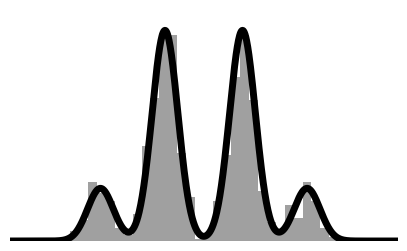

In [145]:

def bimodal_gaussian_1d(mode_offset=0.3, mode_width=0.1):
    # two 1D means: +mode_offset and -mode_offset
    locs = torch.tensor([mode_offset+0.5,mode_offset,
                         -mode_offset,-mode_offset-0.5]).to(DEVICE, dtype=torch.float32)
    # equal weights for the two modes
    mixture = tfd.Categorical(probs=torch.tensor([0.1,0.4, 0.4,0.1], device=DEVICE),
                              validate_args=False)
    # Each component is a 1D Normal
    component = tfd.Normal(loc=locs, scale=mode_width, validate_args=False)
    # The mixture distribution
    return tfd.MixtureSameFamily(mixture, component, validate_args=False)


dist = bimodal_gaussian_1d()

# We have access to the log_prob using dist.log_prob
xscale = torch.tensor(np.linspace(-1.5,1.5,1000))
logp = np.e**dist.log_prob(xscale)

# We can sample from the distribution
samp = dist.sample([1000])
fig, ax = plt.subplots(figsize=(5,3))

ax.plot(xscale,logp,lw=5,c="k")
ax.hist(samp,bins=30,density=True,color="grey",alpha=0.75)
ax.set_xlim(-1.5,1.5)
ax.set_ylim(0,1.75)
ax.axis('off')
fig.savefig("true_hist.png", dpi=300)

In [146]:
# @title
# First define a temperature schedule. We use some foresight and use a geometric series
sigma_x0 = 0.1 # the original width of our modes

sigma_min = 1e-2 # minimum temperature
sigma_max = 2 # maximum temperature
def sigma(t):
  return sigma_min * (sigma_max / sigma_min)**t

def log_prob(x, t):
    """
      Define the distribution at the correct temperature, then evalute log_prob
    """
    width = torch.sqrt(sigma_x0**2 + sigma(t)**2)
    return bimodal_gaussian_1d(mode_width=width).log_prob(x,)

def density(x, t):
    return torch.exp(log_prob(x, t))

In [147]:
# @title
from scipy.stats import gaussian_kde


# fig, axs = plt.subplots(1, 5, figsize=(20, 4),sharey=True)

ts = [0, 0.42,0.52, 0.84, 1]
N = 10000
true_noised_dists = torch.ones((5,1000))
count = 0
for i, t in enumerate(ts):
    # add noise to zero temperature samples
    x = dist.sample([N])
    x_t = x + torch.randn_like(x) * sigma(t)
    # axs[i].hist(x_t,bins=100,density=True)
    # ax_i = density_scatter(x_t.cpu().numpy(), ax=axs[i], bins=10)
    # ax_i = density_contours(lambda x: density(x, torch.tensor(t)), xmin=-_max[i], xmax=_max[i], ymin=-_max[i], ymax=_max[i], confidence_intervals=[0.68, 0.95, 0.999, 0.9999999], ax=ax_i)
    # ax_i.set_ylim(-_max[i], _max[i])
    # ax_i.set_xlim(-_max[i], _max[i])
    # KDE curve
    kde = gaussian_kde(x_t)
    # axs[i].plot(xscale, kde(xscale), linewidth=2)
    # axs[i].set_xlim(-1.5,1.5)
    # axs[i].set_title(f"$\sigma(%.2f) = %.2f$" % (t, sigma(t)))

    true_noised_dists[i] = torch.tensor(kde(xscale))

# Denoising score matching

We are now in a position to learn the score everywhere, simply by adding noise. We just need to condition the network on the time index $t$, since we actually have to the score of all the distributions implied by our temperature schedule.

The score matching objective is modified in the following way
$$
  \mathcal{L}_\theta = \mathbb{E}_{\mathbf{x} \sim p(\mathbf{x})} \mathbb{E}_{t \sim \mathcal{U}(0, 1)} \mathbb{E}_{\mathcal{z} \sim \mathcal{N}(0, 1)} \big[\lambda(t) \lVert \mathbf{s}_\theta(\mathbf{x} + \sigma_t \mathbf{z}, t) - \nabla_{\mathbf{x}} p_t(\mathbf{x} + \sigma_t \mathbf{z} \mid \mathbf{x})\rVert^2 \big]
$$
where $\lambda(t)$ is a weighting factor that we choose to be $\lambda(t) \propto \sigma^2(t)$. We also redefine the model so that it is easier to train
$$
  \mathbf{s}_\theta(\mathbf{x}, t) = \frac{\boldsymbol{\epsilon}_\theta(\mathbf{x}, t)}{\sigma(t)}
$$

In [148]:
def loss_fn(model):
    batch_size = 1028
    x = dist.sample([batch_size]).unsqueeze(1)
    t = torch.rand(batch_size).to(DEVICE)
    z = torch.randn_like(x)
    lambda_t = (sigma(t)**2).view(-1, 1)
    loss = torch.sum(lambda_t * (model(x + sigma(t)[:, None] * z, t) + z / sigma(t)[:, None])**2) / batch_size
    return loss

In [149]:
# @title
class Model(nn.Module):
    def __init__(self, scale=16, embed_dim=32, units=100):
        super().__init__()
        self.nn1 = nn.Linear(1+embed_dim, units)
        self.nn2 = nn.Linear(units, units)
        self.nn3 = nn.Linear(units, 1)
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)
        self.act = nn.SiLU()

    def forward(self, x, t):
        t_proj = t[:, None] * self.W[None, :] * 2 * np.pi
        temb = torch.cat([torch.sin(t_proj), torch.cos(t_proj)], dim=1)
        x = torch.cat([x, temb], dim=1)
        x = self.nn1(x)
        x = self.act(x)
        x = self.nn2(x)
        x = self.act(x)
        x = self.nn3(x) / sigma(t).view(-1, 1) # redefinition here is important
        return x

100%|██████████| 7000/7000 [00:37<00:00, 187.81it/s]


Text(0.5, 0, 'Iteration')

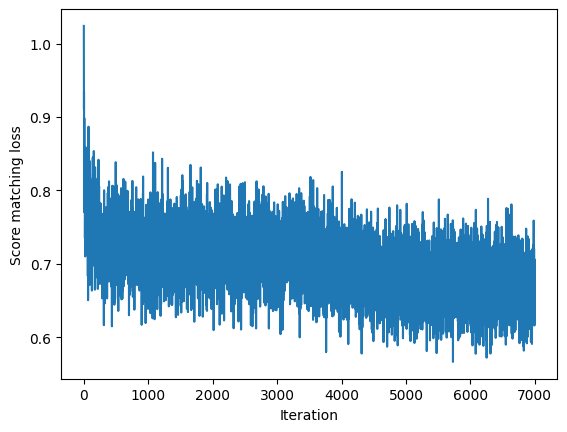

In [150]:
# @title

model = Model()
iterations = 7000
batch_size = 1028
learning_rate = 4e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
losses = []
for _ in tqdm(range(iterations)):
    optimizer.zero_grad()
    x = dist.sample([batch_size])
    t = torch.rand(batch_size).to(DEVICE)
    z = torch.randn_like(x)
    lambda_t = (sigma(t)**2).view(-1, 1)
    loss = loss_fn(model)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
plt.plot(losses)
plt.ylabel("Score matching loss")
plt.xlabel("Iteration")

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
/var/folders/vw/5qpldskx1hn6wrghx5fk63v40000gn/T/ipykernel_37608/1823339095.py:12: SyntaxWarning: invalid escape sequence '\s'
  axs[0,i].set_title(f"$\sigma(%.2f) = %.2f$" % (t, sigma(t)))


torch.Size([400, 1])


Text(0, 0.5, 'True score')

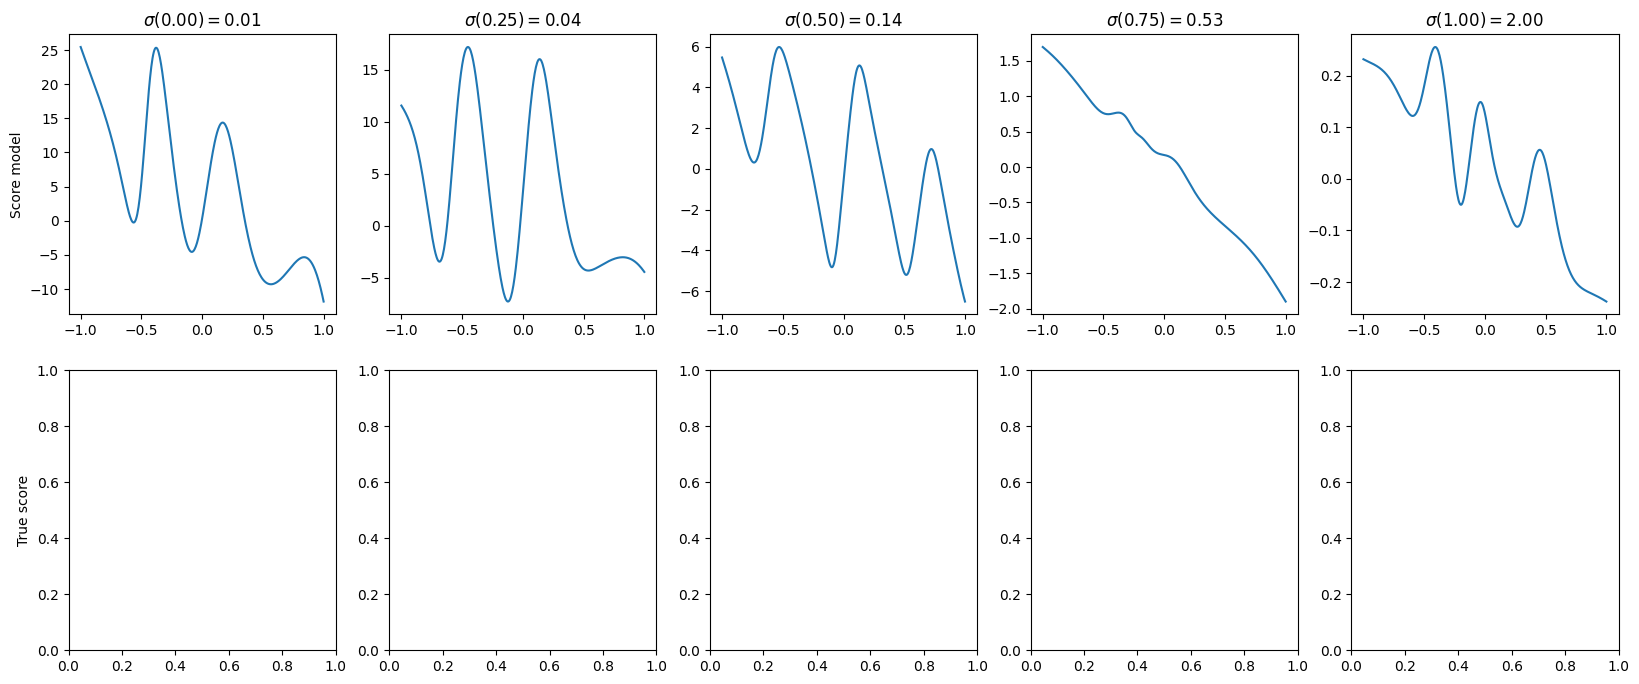

In [151]:
# @title
fig, axs = plt.subplots(2, 5, figsize=(20, 8))


ts = [0, 0.25, 0.5, 0.75, 1]
scales = [1.5e3, 1.5e3, 9e2, 9e1, 1e1]
x = torch.tensor(np.linspace(-1,1,20**2),dtype=torch.float).unsqueeze(1)
print(x.shape)
for i, t in enumerate(ts):
    axs[0,i].plot(x,model(x, torch.ones(20**2).to(DEVICE)*t).detach())
    # axs[1,i].plot(x,true_score(x, torch.ones(20**2).to(DEVICE)*t))
    axs[0,i].set_title(f"$\sigma(%.2f) = %.2f$" % (t, sigma(t)))

axs[0, 0].set_ylabel(r"Score model")
axs[1, 0].set_ylabel(r"True score")

In [152]:
# @title
from torch.func import vmap, grad
def g(t):
    return torch.sqrt(vmap(grad(lambda t: sigma(t)**2))(t))

def forward_euler_maruyama(x, t, dt):
    z = torch.randn_like(x)
    return x + g(t).view(-1, 1) * z * dt**(1/2)
def reversed_euler_maruyama(x, t, dt, score_fn):
    z = torch.randn_like(x)
    return x - g(t).view(-1, 1)**2 * score_fn(x, t) * dt +  g(t).view(-1, 1) * z * (-dt)**(1/2)

In [153]:
x = torch.randn([2500, 1]) * sigma(1.)

len_frames = 20 # note that increasing this number makes diffusion more stable, improves sampling accuracy
ts, dt = np.linspace(1, 0, len_frames, retstep=True)
_max = np.logspace(np.log10(2), np.log10(8), len_frames)[::-1]
x_to_save = torch.ones((5,x.shape[0],x.shape[1]))
with torch.no_grad():
  for i in range(len_frames):
      x = reversed_euler_maruyama(x, torch.ones(x.shape[0]).to(DEVICE) * ts[i], dt, score_fn=model) # <- Use the score model in the diffusion
      # axs[i].hist(x.numpy()[:, 0], bins=70,density=True)
      # # density_contours(lambda x: density(x, torch.tensor(ts[i])), xmin=-_max[i], xmax=_max[i], ymin=-_max[i], ymax=_max[i], confidence_intervals=[0.68, 0.95, 0.999, 0.9999999], ax=axs[i])
      # axs[i].set_title(f"$\sigma(%.2f) = %.2f$" % (ts[i], sigma(ts[i])))
      # axs[i].set_xlim(-5,5)
      if ts[i]==1:
        x_to_save[4] = x
      elif abs(ts[i] - 0.84) < 1e-2:
        x_to_save[3] = x
      elif abs(ts[i] - 0.52) < 1e-2:
        x_to_save[2] = x
      elif abs(ts[i] - 0.42) < 1e-2:
        x_to_save[1] = x
      elif ts[i]==0:
        x_to_save[0] = x


In [154]:
wavelength = np.linspace(540, 560, 6000)

def gaussian(x, amp, mu, ssigma):
    return amp * np.exp(-(x - mu)**2 / (2 * ssigma**2))

# Continuum
flux = np.ones_like(wavelength)

# More, closer-spaced absorption lines
lines = [
    (-0.25, 542.0, 0.25),
    (-0.35, 543.2, 0.12),
    (-0.45, 545.1, 0.38),
    (-0.40, 547.0, 0.13),
    (-0.25, 548.1, 0.17),
    (-0.35, 549.0, 0.12),
    (-0.30, 552.0, 0.22),
    (-0.35, 553.0, 0.11),
    (-0.35, 557.0, 0.41),
    (-0.35, 558.0, 0.21),
]

for amp, mu, ssigma in lines:
    flux += gaussian(wavelength, amp, mu, ssigma)

# Diffusion Plots

0.84
tensor([0.8568])
0.52
tensor([0.1572])
0.42
tensor([0.0926])
0.0
tensor([0.0100])


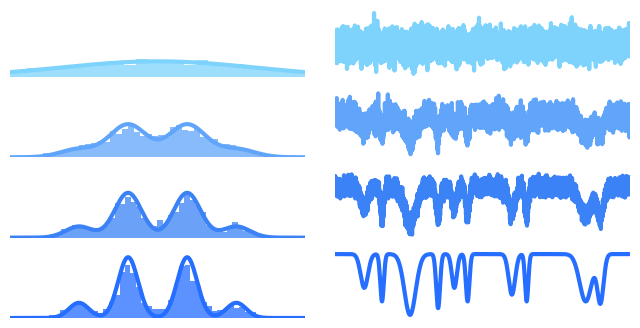

In [159]:
postellar_color  = "#256EFF"
onesig = "#5C92FF"
twosig = "#85ADFF"
threesig = "#ADC9FF"

colors = ["#256EFF", "#3B82F6", "#60A5FA", "#7DD3FC"]
fig, ax = plt.subplots(4,2,figsize=(8,4))
plt.subplots_adjust(wspace=0.1)
ts = [0.84,0.52,0.42,0.0]
sigmas = [0.6,0.12,0.05,0]
count = 0
for i in np.arange(3,-1,-1):
    print(ts[count])
    ax[count,0].plot(xscale,density(xscale,torch.ones(1)*ts[count]),lw=3,c=colors[i])
    ax[count,0].hist(x_to_save[i],bins=50,density=True,color=colors[i],alpha=0.75)
    ax[count,0].set_xlim(-1.5,1.5)
    ax[count,0].set_ylim(0,1.75)
    ax[count,0].axis('off')
    print(sigma(torch.ones(1)*ts[count]))
    altered_flux = torch.tensor(flux)  +  sigmas[count]* torch.randn_like(torch.tensor(flux))
    ax[count,1].plot(wavelength,altered_flux,lw=3,c=colors[i])
    ax[count,1].set_xlim(540,560)
    # ax[count,2].set_ylim(0.5,1.5)
    ax[count,1].axis('off')
    count+=1
    plt.savefig("diffusion1.png", dpi=300)

In [156]:
def bimodal_gaussian_1doops(mode_offset=0.3, mode_width=0.1):
    # two 1D means: +mode_offset and -mode_offset
    locs = torch.tensor([mode_offset+0.45,mode_offset,
                         -mode_offset,-mode_offset-0.45]).to(DEVICE, dtype=torch.float32)
    # equal weights for the two modes
    mixture = tfd.Categorical(probs=torch.tensor([0.01,0.49, 0.49,0.01], device=DEVICE),
                              validate_args=False)
    # Each component is a 1D Normal
    component = tfd.Normal(loc=locs, scale=mode_width, validate_args=False)
    # The mixture distribution
    return tfd.MixtureSameFamily(mixture, component, validate_args=False)


distnon = bimodal_gaussian_1doops()

(-1.5, 1.5, 0.0, 1.95)

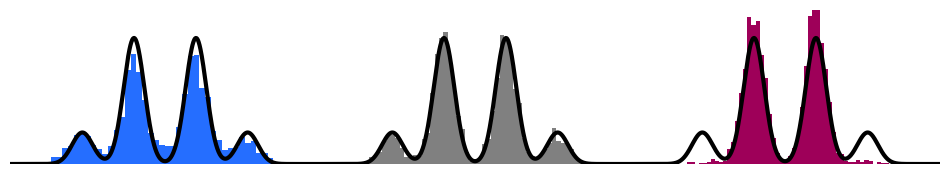

In [157]:
# We can sample from the distribution
samp = dist.sample([2500])
fig, ax = plt.subplots(1,3,figsize=(12,2),sharey=True)
plt.subplots_adjust(wspace=0)
ax[0].plot(xscale,logp,lw=3,c="k")
ax[0].hist(x_to_save[0],bins=50,density=True,color="#256EFF")
ax[0].set_xlim(-1.5,1.5)
ax[0].set_ylim(0,1.75)
ax[0].axis('off')

ax[1].plot(xscale,logp,lw=3,c="k")
ax[1].hist(samp,bins=50,density=True,color="grey")
ax[1].set_xlim(-1.5,1.5)
ax[1].set_ylim(0,1.75)
ax[1].axis('off')

ax[2].hist(distnon.sample([2500]),bins=50,density=True,color="#9E0059")
ax[2].set_xlim(-1.5,1.5)
ax[2].plot(xscale,np.e**dist.log_prob(xscale),linewidth=3,c="k")
ax[2].set_ylim(0,1.95)
ax[2].axis('off')
# plt.savefig("not_right_dist.png", dpi=300)